# AG News: data exploration

This notebook explores the AG News dataset used by the classification experiment. It downloads the dataset on first use.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer

plt.style.use('seaborn-v0_8-whitegrid')
LABELS = ['World', 'Sports', 'Business', 'Sci/Tech']
SEED = 42

In [2]:
dataset = load_dataset('ag_news')
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

for frame in (train_df, test_df):
    frame['category'] = frame['label'].map(dict(enumerate(LABELS)))
    frame['word_count'] = frame['text'].str.split().str.len()
    frame['char_count'] = frame['text'].str.len()

print(f'Train rows: {len(train_df):,} | Test rows: {len(test_df):,}')
train_df[['text', 'label', 'category', 'word_count', 'char_count']].head()

Train rows: 120,000 | Test rows: 7,600


,text,label,category,word_count,char_count
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business,21,144
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business,36,266
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business,36,232
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business,36,256
4,"Oil prices soar to all-time record, posing new...",2,Business,37,234


## Class balance

AG News has four topic labels. Comparing both splits confirms whether the evaluation distribution matches training.

,Train,Test
category,,
World,30000,1900
Sports,30000,1900
Business,30000,1900
Sci/Tech,30000,1900


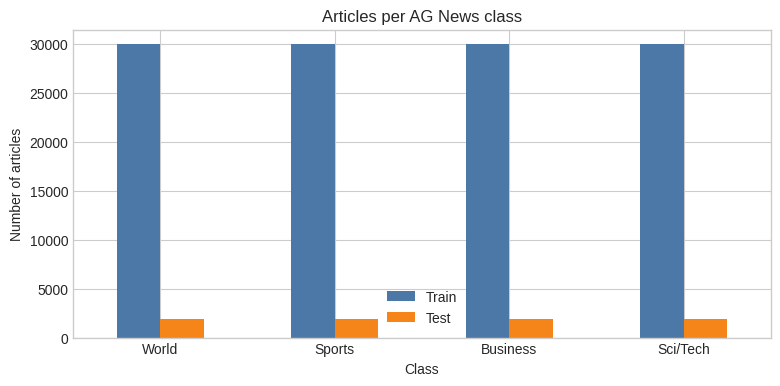

In [3]:
counts = pd.DataFrame({
    'Train': train_df['category'].value_counts().reindex(LABELS),
    'Test': test_df['category'].value_counts().reindex(LABELS),
})
display(counts)
ax = counts.plot.bar(figsize=(9, 4), color=['#4C78A8', '#F58518'])
ax.set(title='Articles per AG News class', xlabel='Class', ylabel='Number of articles')
plt.xticks(rotation=0)
plt.show()

## Article length

The experiment truncates inputs at 128 tokens, so these summaries show how much article text that setting generally covers.

word_count                                            char_count  \
              count  mean   std   min   25%   50%   75%    max      count   
category                                                                    
Business    30000.0  37.5   8.1   8.0  32.0  37.0  42.0  134.0    30000.0   
Sci/Tech    30000.0  37.2  12.4   8.0  30.0  36.0  42.0  177.0    30000.0   
Sports      30000.0  37.8   8.9   8.0  32.0  37.0  42.0  151.0    30000.0   
World       30000.0  38.9  10.3  11.0  33.0  39.0  44.0  145.0    30000.0   

                                                           
           mean   std    min    25%    50%    75%     max  
category                                                   
Business  241.4  64.3  100.0  204.0  236.0  267.0  1006.0  
Sci/Tech  237.2  82.2  100.0  190.0  230.0  268.0  1012.0  
Sports    224.7  50.5  100.0  190.0  220.0  251.0   853.0  
World     242.6  63.6  100.0  204.0  243.0  276.0   865.0

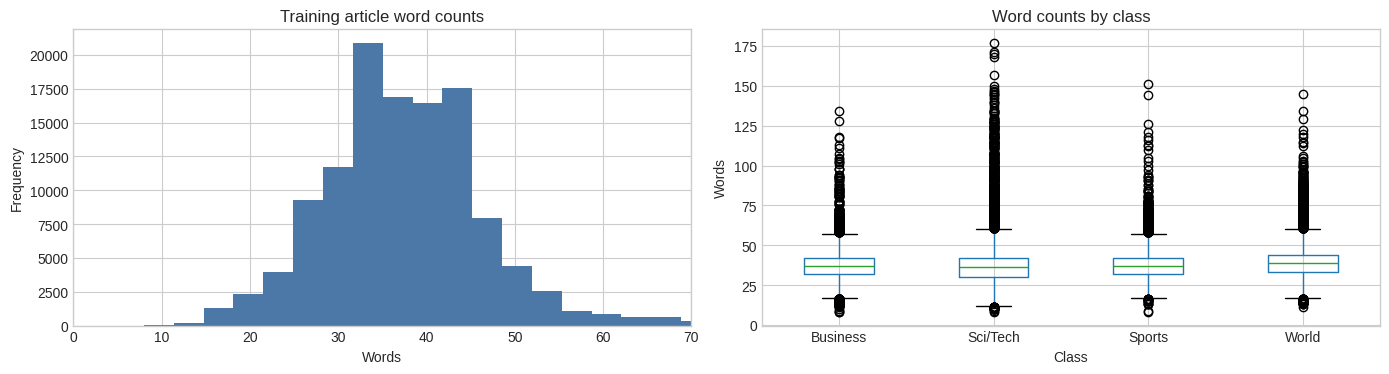

In [4]:
display(train_df.groupby('category')[['word_count', 'char_count']].describe().round(1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_df['word_count'].plot.hist(bins=50, ax=axes[0], color='#4C78A8')
axes[0].set(title='Training article word counts', xlabel='Words', xlim=(0, train_df['word_count'].quantile(0.99)))
train_df.boxplot(column='word_count', by='category', ax=axes[1])
axes[1].set(title='Word counts by class', xlabel='Class', ylabel='Words')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Topic vocabulary and examples

A small TF-IDF analysis highlights terms that are distinctive within each topic; it is descriptive EDA, not the trained baseline pipeline.

In [5]:
sample = train_df.groupby('category', group_keys=False).sample(n=3000, random_state=SEED)
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2), min_df=3)
matrix = vectorizer.fit_transform(sample['text'])
terms = vectorizer.get_feature_names_out()
top_terms = {}
for label in LABELS:
    mean_scores = matrix[sample['category'].eq(label).to_numpy()].mean(axis=0).A1
    top_terms[label] = terms[mean_scores.argsort()[-10:][::-1]].tolist()
pd.DataFrame(top_terms).T.rename_axis('category').rename(columns=lambda i: f'#{i + 1}')

,#1,#2,#3,#4,#5,#6,#7,#8,#9,#10
category,,,,,,,,,,
World,iraq,ap,39,said,reuters,president,minister,afp,killed,government
Sports,39,ap,game,win,season,team,night,league,cup,victory
Business,39,oil,reuters,said,prices,new,stocks,company,gt,lt
Sci/Tech,39,microsoft,new,software,internet,space,ap,gt,lt,quot


In [6]:
examples = (train_df.groupby('category', group_keys=False)
            .sample(n=1, random_state=SEED)[['category', 'text']]
            .sort_values('category'))
for row in examples.itertuples(index=False):
    print(f'[{row.category}] {row.text}\n')

[Business] US house sales fall in July Sales of non-new houses in the US fell last month but still exceeded analyst forecasts.

[Sci/Tech] Intuit Posts 1Q Loss; Revenue Up 11 Pct. (AP) AP - Intuit Inc. posted a narrower net loss for its latest quarter as increased revenue from its QuickBooks accounting software helped boost results.

[Sports] Benitez pleased to have avoided Italian team in draw Rafael Benitez says he is happy Liverpool have avoided an Italian team after being drawn to play Bayer Leverkusen in the Champions League.

[World] AdWatch: Kerry Accuses Bush on Iraq Money (AP) AP - Details of new television ad from Democratic presidential candidate John Kerry, that began airing Wednesday.

